# Differenslikninger

```{admonition} Læringsutbytte
Etter å ha arbeidet med denne delen av emnet, skal du kunne:

1. forklare forskjellen mellom diskrete og kontinuerlige modeller
2. formulere en enkel differenslikning som beskriver utviklingen fra ett steg til det neste
3. bruke løkker og arrayer til å simulere et dynamisk system iterativt
4. modellere nedbrytning, tilførsel og akkumulering av kjemiske stoffer
5. kontrollere en modell ved å undersøke enheter, grenser og langsiktig oppførsel
```

Mange prosesser kan beskrives ved å finne en regel som forteller hvordan systemet går fra ett steg til det neste. Det kan være mengden av et stoff fra én dag til den neste, en konsentrasjon etter hvert reaksjonstrinn eller en dose som tilføres med jevne mellomrom.

Når samme regel gjentas mange ganger, passer problemet naturlig til en løkke. Hver gjennomkjøring av løkka er en **iterasjon**, og vi kan derfor si at vi løser problemet iterativt.

En **diskret modell** beskriver systemet ved bestemte steg,

$$x_0,\;x_1,\;x_2,\ldots$$

mens en **kontinuerlig modell** beskriver tilstanden som en funksjon av en kontinuerlig variabel, for eksempel $c(t)$. Forskjellen handler om hvordan modellen er formulert – ikke om hvorvidt vi tilfeldigvis har målt systemet mellom punktene.

## Iterativ tenkning med en enkel følge

Vi starter med noe helt enkelt. I den aritmetiske følgen

$$1,4,7,10,13,\ldots$$

får vi neste ledd ved å legge til 3:

$$x_{n+1}=x_n+3.$$

Indeksen $n$ betyr bare «hvilket steg vi er på». Hvis vi starter med $x_0=1$, blir

$$x_1=x_0+3=4,$$

og deretter

$$x_2=x_1+3=7.$$

Det er akkurat denne prosessen en løkke kan gjenta.


In [1]:
x = 1
n = 10

for k in range(1, n):
    x = x + 3

print("Det tiende leddet er", x)


Det tiende leddet er 28


Det matematiske problemet er enkelt, men arbeidsmåten er viktig: Vi trenger ikke nødvendigvis en ferdig formel for ledd nummer $n$. Hvis vi kjenner **oppdateringsregelen**, kan datamaskinen gjenta den så mange ganger vi ønsker.

```{admonition} Underveisoppgave
:class: tip
Finn det hundrede tallet i den geometriske følgen $1,2,4,8,16,\ldots$ ved hjelp av en løkke.
```

I kjemi blir denne tankemåten interessant når oppdateringsregelen representerer en fysisk prosess.


I kjemi blir dette mer interessant når oppdateringsregelen representerer en fysisk prosess.

## Kjemisk eksempel: nedbrytning med halveringstid

Anta at et stoff har halveringstid $H$. Hvis hvert tidssteg har lengde $\Delta t$, er andelen som er igjen etter ett steg

$$r=0.5^{\Delta t/H}.$$

Den diskrete modellen blir derfor

$$m_{n+1}=m_n\,0.5^{\Delta t/H}.$$

Legg merke til at eksponenten inneholder **steglengden** $\Delta t$, ikke den totale tiden $t$.


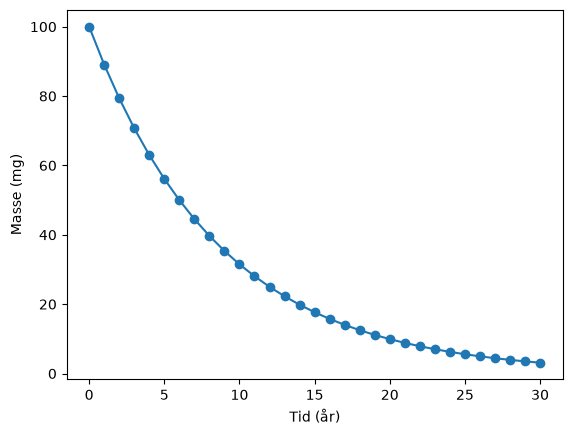

In [2]:
import numpy as np
import matplotlib.pyplot as plt

m0 = 100.0      # mg
H = 6.0         # år
dt = 1.0        # år
antall_ar = 30

tid = np.arange(0, antall_ar + dt, dt)
masse = np.zeros(len(tid))
masse[0] = m0

faktor = 0.5**(dt/H)

for n in range(len(tid) - 1):
    masse[n + 1] = masse[n] * faktor

plt.plot(tid, masse, "o-")
plt.xlabel("Tid (år)")
plt.ylabel("Masse (mg)")
plt.show()


Her kunne vi også brukt den lukkede formelen direkte. Verdien av den iterative modellen blir tydeligere når noe **endrer seg underveis**.

## Tilførsel og fjerning samtidig

Anta at en miljøgift i en innsjø brytes ned med en fast andel per år, samtidig som det tilføres en viss masse fra et nedbørfelt. Da kan en enkel modell være

$$m_{n+1}=r\,m_n+I_n,$$

der $r$ er andelen som er igjen etter ett år og $I_n$ er tilførselen i år $n$.

Hvis et tiltak reduserer utslippet etter ti år, kan vi endre $I_n$ inne i løkka.


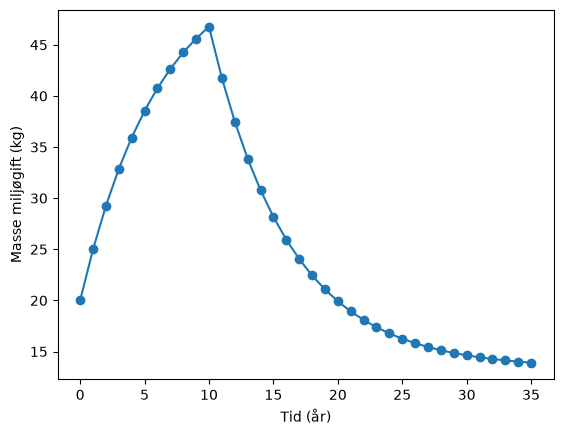

In [3]:
antall_ar = 35
tid = np.arange(antall_ar + 1)
masse = np.zeros(antall_ar + 1)

masse[0] = 20.0
andel_igjen = 0.85

for n in range(antall_ar):
    if n < 10:
        tilforsel = 8.0
    else:
        tilforsel = 2.0

    masse[n + 1] = andel_igjen*masse[n] + tilforsel

plt.plot(tid, masse, "o-")
plt.xlabel("Tid (år)")
plt.ylabel("Masse miljøgift (kg)")
plt.show()


```{admonition} Underveisoppgave
:class: tip
Hva ville systemet nærmet seg dersom tilførselen var konstant 8,0 kg/år for alltid? Endre programmet og undersøk. Kan du forklare hvorfor grafen flater ut?
```

### Prøv selv

Modifiser tilførsel, nedbrytning og tidspunktet for tiltaket.

<iframe src="../../basthon/?from=examples/differenslikning_miljogift.py" width="100%" height="620" frameborder="0" title="Prøv selv: differenslikning for miljøgift" loading="lazy" allowfullscreen></iframe>

## Gjentatt dosering

Samme type modell kan brukes når et stoff tilføres med jevne mellomrom og samtidig fjernes fra systemet.

Hvis 80 % av et legemiddel er igjen før neste dose, og dosen er 100 mg, kan en enkel daglig modell skrives

$$m_{n+1}=0.80m_n+100.$$


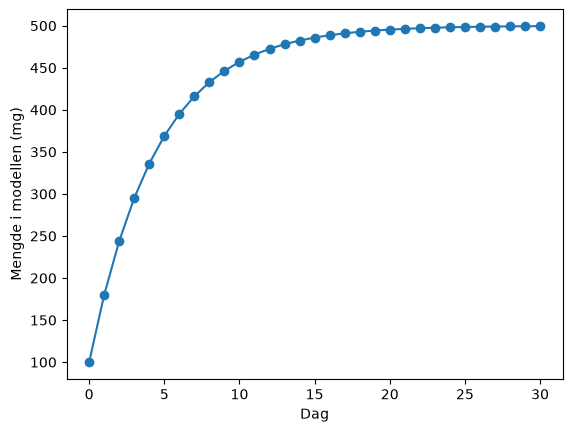

In [4]:
dose = 100.0
andel_igjen = 0.80
dager = 30

tid = np.arange(dager + 1)
mengde = np.zeros(dager + 1)
mengde[0] = dose

for n in range(dager):
    mengde[n + 1] = andel_igjen*mengde[n] + dose

plt.plot(tid, mengde, "o-")
plt.xlabel("Dag")
plt.ylabel("Mengde i modellen (mg)")
plt.show()


```{admonition} Modell, ikke doseringsråd
:class: warning
Dette er en matematisk modell for å øve på differenslikninger. Virkelige legemidler kan være mye mer komplekse, og modellen skal ikke brukes til å bestemme faktisk dosering.
```

## Fra differenslikning til differensiallikning

Differenslikninger er diskrete modeller i sin egen rett. Men de blir også viktige i neste kapittel.

Hvis vi kjenner en kontinuerlig endringsrate

$$\frac{dx}{dt}=f(t,x),$$

kan vi lage den diskrete oppdateringen

$$x_{n+1}=x_n+f(t_n,x_n)\Delta t.$$

Dette er Eulers metode. Dermed fungerer differenslikninger som en naturlig bro mellom programmering med løkker og kontinuerlige dynamiske modeller.

## Kort oppsummering

- En diskret modell beskriver tilstanden ved bestemte steg.
- En differenslikning kobler sammen etterfølgende verdier.
- Iterative modeller er særlig nyttige når parametre eller tilførsler endrer seg underveis.
- Kjemiske modeller bør kontrolleres med enheter, grenser og stoff-/massebalanse.


## Oppgaver

```{admonition} Oppgave 1 – geometrisk følge
:class: tip
Bruk en differenslikning til å finne det hundrede leddet i følgen $1,2,4,8,\ldots$.
```

```{admonition} Oppgave 2 – halveringstid
:class: tip
Et stoff har halveringstid 4,5 år. Start med 250 mg og bruk tidssteg på 0,5 år. Simuler 30 år og sammenlikn verdien etter 30 år med den analytiske formelen.
```

```{admonition} Oppgave 3 – tidssteg
:class: tip
Gjenta oppgave 2 med tidssteg på 1 år og 0,1 år. Siden oppdateringsfaktoren bruker $0.5^{\Delta t/H}$, skal verdiene ved samme fysiske tid bli svært like. Forklar hvorfor.
```

```{admonition} Oppgave 4 – miljøgift med tiltak
:class: tip
Lag en modell der 90 % av en miljøgift blir igjen fra år til år, og 5 kg tilføres hvert år. Etter 15 år reduseres tilførselen til 1 kg/år. Plott utviklingen i 50 år.
```

```{admonition} Oppgave 5 – likevektsverdi i en diskret modell
:class: tip
For modellen $m_{n+1}=0.85m_n+8$, finn numerisk hvilken verdi systemet nærmer seg. Sett deretter $m_{n+1}=m_n$ og finn den samme verdien algebraisk.
```

```{admonition} Oppgave 6 – pulserende tilførsel
:class: tip
En reaktor får tilført 10 mg av et stoff hvert femte tidssteg, mens 10 % brytes ned per steg. Lag en modell og plott minst 60 tidssteg. Hva kjennetegner grafen?
```

```{admonition} Oppgave 7 – lag din egen kjemiske regel
:class: tip
Velg et system med tilførsel og/eller fjerning av et stoff. Formuler én differenslikning, forklar alle leddene og enhetene, og implementer modellen i Python.
```


## Video

<iframe width="850" height="450" src="https://www.youtube.com/embed/u6wgr0GRoLM" title="Differenslikninger" frameborder="0" allowfullscreen></iframe>
